In [ ]:
!pip uninstall -y datasets
!pip install datasets==3.6.0

In [1]:
import datasets
print(datasets.__version__)

3.6.0


In [2]:
from datasets import load_dataset, Dataset, concatenate_datasets


In [ ]:
from collections import OrderedDict

_FLEURS_LANG = sorted(["af_za", "am_et", "ar_eg", "as_in", "ast_es", "az_az", "be_by", "bn_in", "bs_ba", "ca_es", "ceb_ph", "cmn_hans_cn", "yue_hant_hk", "cs_cz", "cy_gb", "da_dk", "de_de", "el_gr", "en_us", "es_419", "et_ee", "fa_ir", "ff_sn", "fi_fi", "fil_ph", "fr_fr", "ga_ie", "gl_es", "gu_in", "ha_ng", "he_il", "hi_in", "hr_hr", "hu_hu", "hy_am", "id_id", "ig_ng", "is_is", "it_it", "ja_jp", "jv_id", "ka_ge", "kam_ke", "kea_cv", "kk_kz", "km_kh", "kn_in", "ko_kr", "ckb_iq", "ky_kg", "lb_lu", "lg_ug", "ln_cd", "lo_la", "lt_lt", "luo_ke", "lv_lv", "mi_nz", "mk_mk", "ml_in", "mn_mn", "mr_in", "ms_my", "mt_mt", "my_mm", "nb_no", "ne_np", "nl_nl", "nso_za", "ny_mw", "oc_fr", "om_et", "or_in", "pa_in", "pl_pl", "ps_af", "pt_br", "ro_ro", "ru_ru", "bg_bg", "sd_in", "sk_sk", "sl_si", "sn_zw", "so_so", "sr_rs", "sv_se", "sw_ke", "ta_in", "te_in", "tg_tj", "th_th", "tr_tr", "uk_ua", "umb_ao", "ur_pk", "uz_uz", "vi_vn", "wo_sn", "xh_za", "yo_ng", "zu_za"])
_FLEURS_LANG_TO_ID = OrderedDict([("Afrikaans", "af"), ("Amharic", "am"), ("Arabic", "ar"), ("Armenian", "hy"), ("Assamese", "as"), ("Asturian", "ast"), ("Azerbaijani", "az"), ("Belarusian", "be"), ("Bengali", "bn"), ("Bosnian", "bs"), ("Bulgarian", "bg"), ("Burmese", "my"), ("Catalan", "ca"), ("Cebuano", "ceb"), ("Mandarin Chinese", "cmn_hans"), ("Cantonese Chinese", "yue_hant"), ("Croatian", "hr"), ("Czech", "cs"), ("Danish", "da"), ("Dutch", "nl"), ("English", "en"), ("Estonian", "et"), ("Filipino", "fil"), ("Finnish", "fi"), ("French", "fr"), ("Fula", "ff"), ("Galician", "gl"), ("Ganda", "lg"), ("Georgian", "ka"), ("German", "de"), ("Greek", "el"), ("Gujarati", "gu"), ("Hausa", "ha"), ("Hebrew", "he"), ("Hindi", "hi"), ("Hungarian", "hu"), ("Icelandic", "is"), ("Igbo", "ig"), ("Indonesian", "id"), ("Irish", "ga"), ("Italian", "it"), ("Japanese", "ja"), ("Javanese", "jv"), ("Kabuverdianu", "kea"), ("Kamba", "kam"), ("Kannada", "kn"), ("Kazakh", "kk"), ("Khmer", "km"), ("Korean", "ko"), ("Kyrgyz", "ky"), ("Lao", "lo"), ("Latvian", "lv"), ("Lingala", "ln"), ("Lithuanian", "lt"), ("Luo", "luo"), ("Luxembourgish", "lb"), ("Macedonian", "mk"), ("Malay", "ms"), ("Malayalam", "ml"), ("Maltese", "mt"), ("Maori", "mi"), ("Marathi", "mr"), ("Mongolian", "mn"), ("Nepali", "ne"), ("Northern-Sotho", "nso"), ("Norwegian", "nb"), ("Nyanja", "ny"), ("Occitan", "oc"), ("Oriya", "or"), ("Oromo", "om"), ("Pashto", "ps"), ("Persian", "fa"), ("Polish", "pl"), ("Portuguese", "pt"), ("Punjabi", "pa"), ("Romanian", "ro"), ("Russian", "ru"), ("Serbian", "sr"), ("Shona", "sn"), ("Sindhi", "sd"), ("Slovak", "sk"), ("Slovenian", "sl"), ("Somali", "so"), ("Sorani-Kurdish", "ckb"), ("Spanish", "es"), ("Swahili", "sw"), ("Swedish", "sv"), ("Tajik", "tg"), ("Tamil", "ta"), ("Telugu", "te"), ("Thai", "th"), ("Turkish", "tr"), ("Ukrainian", "uk"), ("Umbundu", "umb"), ("Urdu", "ur"), ("Uzbek", "uz"), ("Vietnamese", "vi"), ("Welsh", "cy"), ("Wolof", "wo"), ("Xhosa", "xh"), ("Yoruba", "yo"), ("Zulu", "zu")])
_FLEURS_LANG_SHORT_TO_LONG = {v: k for k, v in _FLEURS_LANG_TO_ID.items()}
_FLEURS_LONG_TO_LANG = {_FLEURS_LANG_SHORT_TO_LONG["_".join(k.split("_")[:-1]) or k]: k for k in _FLEURS_LANG}
_FLEURS_GROUP_TO_LONG = OrderedDict({
    "western_european_we": ["Asturian", "Bosnian", "Catalan", "Croatian", "Danish", "Dutch", "English", "Finnish", "French", "Galician", "German", "Greek", "Hungarian", "Icelandic", "Irish", "Italian", "Kabuverdianu", "Luxembourgish", "Maltese", "Norwegian", "Occitan", "Portuguese", "Spanish", "Swedish", "Welsh"],
    "eastern_european_ee": ["Armenian", "Belarusian", "Bulgarian", "Czech", "Estonian", "Georgian", "Latvian", "Lithuanian", "Macedonian", "Polish", "Romanian", "Russian", "Serbian", "Slovak", "Slovenian", "Ukrainian"],
    "central_asia_middle_north_african_cmn": ["Arabic", "Azerbaijani", "Hebrew", "Kazakh", "Kyrgyz", "Mongolian", "Pashto", "Persian", "Sorani-Kurdish", "Tajik", "Turkish", "Uzbek"],
    "sub_saharan_african_ssa": ["Afrikaans", "Amharic", "Fula", "Ganda", "Hausa", "Igbo", "Kamba", "Lingala", "Luo", "Northern-Sotho", "Nyanja", "Oromo", "Shona", "Somali", "Swahili", "Umbundu", "Wolof", "Xhosa", "Yoruba", "Zulu"],
    "south_asian_sa": ["Assamese", "Bengali", "Gujarati", "Hindi", "Kannada", "Malayalam", "Marathi", "Nepali", "Oriya", "Punjabi", "Sindhi", "Tamil", "Telugu", "Urdu"],
    "south_east_asian_sea": ["Burmese", "Cebuano", "Filipino", "Indonesian", "Javanese", "Khmer", "Lao", "Malay", "Maori", "Thai", "Vietnamese"],
    "chinese_japanase_korean_cjk": ["Mandarin Chinese", "Cantonese Chinese", "Japanese", "Korean"],
})

# Get ids of all eastern european languages
eastern_ids = [_FLEURS_LONG_TO_LANG[lang] for lang in _FLEURS_GROUP_TO_LONG["eastern_european_ee"]]
print(eastern_ids)
# print(_FLEURS_LONG_TO_LANG)

In [4]:
LANGS = ['hy_am','be_by','bg_bg','cs_cz','et_ee','ka_ge','lv_lv','lt_lt',
    'mk_mk','pl_pl','ro_ro','ru_ru','sr_rs','sk_sk','sl_si','uk_ua']

per_lang = 500

Data taken from training, testing and validation parts of fleurs dataset. Predictions not great.

In [ ]:
train_list = []
val_list = []
test_list = []

for i, lang in enumerate(LANGS):
    tr = load_dataset(
        "google/fleurs",
        lang,
        split="train",
        streaming=True
    )
    val = load_dataset(
        "google/fleurs",
        lang,
        split="validation",
        streaming=True
    )

    tst = load_dataset(
        "google/fleurs",
        lang,
        split="test",
        streaming=True
    )

    # take first 500
    training = []
    for j, ex in enumerate(tr):
        if j >= per_lang:
            break
        ex["lang_id"] = i
        training.append(ex)
    train_small = Dataset.from_list(training)
    train_list.append(train_small)
    # print("got training")

    # take first 100
    validation = []
    for j, ex in enumerate(val):
        if j >= 100:
            break
        ex["lang_id"] = i
        validation.append(ex)
    val_small = Dataset.from_list(validation)
    val_list.append(val_small)
    # print("got validation")

    # # take first 100
    testing = []
    for j, ex in enumerate(tst):
        if j >= 25:
            break
        ex["lang_id"] = i
        testing.append(ex)
    tst_small = Dataset.from_list(testing)
    test_list.append(tst_small)
    # print("got testing")

train_ds = concatenate_datasets(train_list)
val_ds = concatenate_datasets(val_list)
test_ds = concatenate_datasets(test_list)

train_ds = train_ds.shuffle(seed=42)
val_ds = val_ds.shuffle(seed=42)
test_ds = test_ds.shuffle(seed=42)

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))

Test size: 400


Takes all data from training section of fleurs, better predictions for data

In [5]:
#split the training data in to 3 for train val and test

train_list = []
val_list = []
test_list = []

for i, lang in enumerate(LANGS):
    tr = load_dataset(
        "google/fleurs",
        lang,
        split="train",
        streaming=True,
        trust_remote_code=True
    )

    # take first 500
    training = []
    validation = []
    testing = []
    for j, ex in enumerate(tr):
        if j < 100:
            ex["lang_id"] = i
            testing.append(ex)
        elif j < 200:
            ex["lang_id"] = i
            validation.append(ex)
        else:
            ex["lang_id"] = i
            training.append(ex)
        if j % 1000 == 0:
            print(j, "data downloaded")
    train_small = Dataset.from_list(training)
    train_list.append(train_small)
    val_small = Dataset.from_list(validation)
    val_list.append(val_small)
    tst_small = Dataset.from_list(testing)
    test_list.append(tst_small)
    # print("got training")

train_ds = concatenate_datasets(train_list)
val_ds = concatenate_datasets(val_list)
test_ds = concatenate_datasets(test_list)

train_ds = train_ds.shuffle(seed=42)
val_ds = val_ds.shuffle(seed=42)
test_ds = test_ds.shuffle(seed=42)

# ds = ds.train_test_split(test_size=0.3, seed=42, stratify_by_column="lang_id")
# temp_ds = ds["test"].train_test_split(test_size=0.3, seed=42, stratify_by_column="lang_id")

# train_ds = ds["train"]
# val_ds = temp_ds["train"]
# test_ds = temp_ds["test"]

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

0 data downloaded
1000 data downloaded
2000 data downloaded
3000 data downloaded


0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
0 data downloaded
1000 data downloaded
2000 data downloaded
Train size: 37963
Validation size: 1600
Test size: 1600


In [ ]:
train_ds[0]

In [25]:
print(train_ds.unique('lang_id'))
print(train_ds.unique('language'))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
['Armenian', 'Belarusian', 'Bulgarian', 'Czech', 'Estonian', 'Georgian', 'Latvian', 'Lithuanian', 'Macedonian', 'Polish', 'Romanian', 'Russian', 'Serbian', 'Slovak', 'Slovenian', 'Ukrainian']


Preprocessing/collate

In [7]:
from torch.nn.utils.rnn import pad_sequence
import torch
import torchaudio

TARGET_SR = 16000 # Input is 16kHz
N_MELS = 80 # Convert to 80-dim log-mel spectrograms

labels = train_ds.unique("lang_id")
print(labels)
print(val_ds.unique("lang_id"))

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=400,
    hop_length=160,
    n_mels=N_MELS,
)

amp_to_db = torchaudio.transforms.AmplitudeToDB()
def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    """
    waveform: [1, N] (mono)
    returns: [T, F] where F=80
    """
    m = mel(waveform)
    m = amp_to_db(m)
    m = (m - m.mean()) / (m.std() + 1e-6)
    m = m.squeeze(0).transpose(0, 1).contiguous()

    return m

def collate_fn(batch):
    feats_list = []
    lengths = []
    target_labels = []

    for ex in batch:
        audio = ex["audio"]
        wav = torch.tensor(audio["array"], dtype=torch.float32).unsqueeze(0)
        # sr = int(audio["sampling_rate"])

        feats = waveform_to_logmel(wav)  # [T,F]
        feats = (feats - feats.mean(dim=0, keepdim=True)) / (feats.std(dim=0, keepdim=True) + 1e-8)

        feats_list.append(feats)
        lengths.append(feats.shape[0])

        target_labels.append(labels.index(ex["lang_id"])) # Convert language ID to index in labels list

    lengths = torch.tensor(lengths, dtype=torch.long)
    target_labels = torch.tensor(target_labels, dtype=torch.long)

    # Pad sequences to the max length in the batch
    padded = pad_sequence(feats_list, batch_first=True)  # [B,Tmax,F]
    return padded, lengths, target_labels


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

CNN creation

In [9]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, input_dim=80, hidden_dim=128, num_classes=16): #number of languages used
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, 5, padding=2),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_dim, hidden_dim*2, 5, padding=2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_dim*2, hidden_dim*2, 3, padding=1),
            nn.BatchNorm1d(hidden_dim*2),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # [B, F, T]
        x = self.conv(x)
        x = x.mean(dim=-1)     # global average pooling
        return self.classifier(x)

Model creation, setting up optimizer, criterion, etc.

In [12]:
import torch.optim as optim
EE_model = CNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EE_model = EE_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(EE_model.parameters(), lr=2e-5)

Train and eval scripts

In [18]:
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    # total_loss = 0
    total_loss, correct, total = 0.0, 0, 0


    for x, lengths, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, lengths, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            preds = logits.argmax(dim=1)

            total_loss += loss.item() * y.size(0)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss/total, correct/total


Epoch training

In [19]:
import copy

num_epochs = 5

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train(EE_model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(EE_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{num_epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")



Epoch 01/5 | train_loss=2.2200 train_acc=0.3694 | val_loss=2.1051 val_acc=0.4288
Epoch 02/5 | train_loss=2.0058 train_acc=0.4499 | val_loss=1.9305 val_acc=0.4988
Epoch 03/5 | train_loss=1.8048 train_acc=0.5203 | val_loss=1.7419 val_acc=0.5725
Epoch 04/5 | train_loss=1.6270 train_acc=0.5813 | val_loss=1.5493 val_acc=0.6088
Epoch 05/5 | train_loss=1.4632 train_acc=0.6337 | val_loss=1.4159 val_acc=0.6312

Training finished. Best val_acc=-1.0000 at epoch -1.


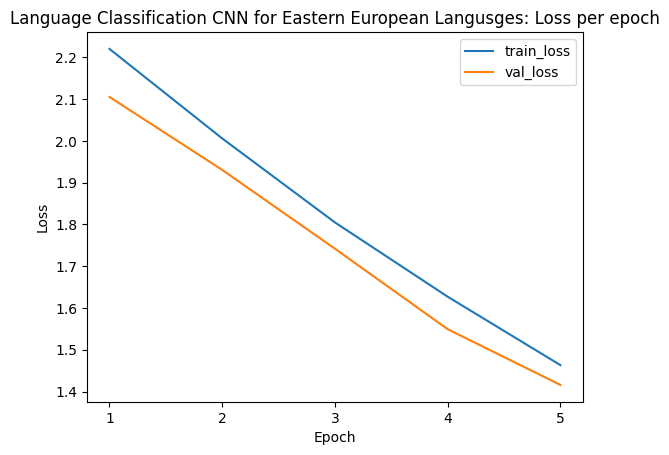

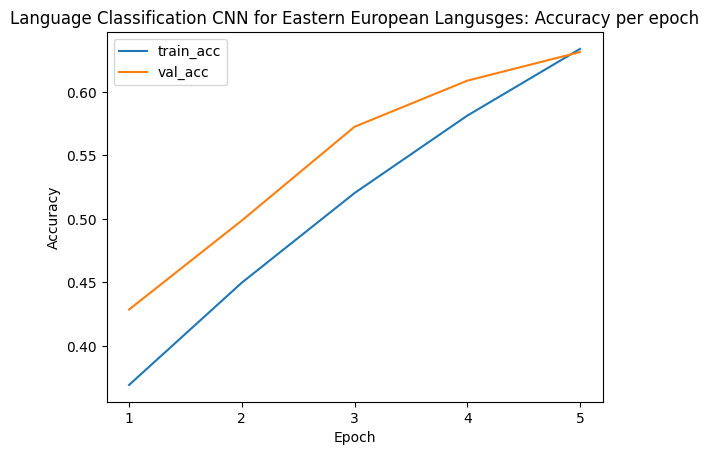

In [21]:
import matplotlib.pyplot as plt

num_epochs = len(history["train_loss"])
epochs = list(range(1, num_epochs + 1))

plt.figure()
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.legend()
plt.title("Language Classification CNN for Eastern European Languages: Loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, num_epochs+1, max(1, num_epochs//10)))
plt.show()

plt.figure()
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.legend()
plt.title("Language Classification CNN for Eastern European Languages: Accuracy per epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(1, num_epochs+1, max(1, num_epochs//10)))
plt.show()

In [23]:
test_loss, test_acc = evaluate(EE_model, test_loader, criterion, device)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.6075


In [22]:
all_preds = []
for x, lengths, y in test_loader:
    x = x.to(device)
    logits = EE_model(x)
    preds = torch.argmax(logits, dim=1)
    all_preds.extend(preds.cpu().tolist())

from collections import Counter
print(Counter(all_preds))

Counter({0: 226, 10: 213, 9: 151, 12: 140, 2: 112, 4: 112, 15: 110, 7: 108, 6: 97, 1: 97, 3: 91, 14: 72, 8: 42, 11: 23, 13: 5, 5: 1})


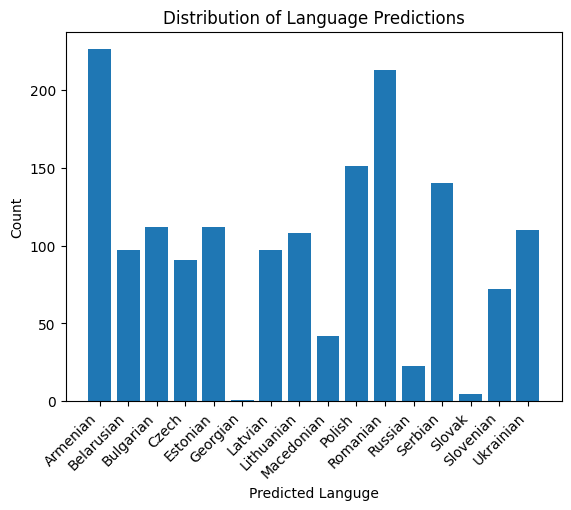

In [30]:
counts = Counter(all_preds)

classes = sorted(counts.keys())
labels = ['Armenian', 'Belarusian', 'Bulgarian', 'Czech', 'Estonian', 'Georgian', 'Latvian', 'Lithuanian', 'Macedonian', 'Polish', 'Romanian', 'Russian', 'Serbian', 'Slovak', 'Slovenian', 'Ukrainian']
values = [counts[c] for c in classes]

plt.figure()
plt.bar(labels, values)
plt.xlabel("Predicted Languge")
plt.ylabel("Count")
plt.title("Distribution of Language Predictions")

plt.xticks(rotation=45, ha='right')
plt.show()